# Self-Play from Scratch: A Toy Example

## The Core Idea in 5 Minutes

Before diving into LLMs and GPU clusters, let's prove that self-play works using a tiny example you can run **on your laptop in under a minute, with no GPU**.

We'll train a small neural network to do **single-digit addition** (e.g., 3 + 7 = 10). The network gets a brief supervised warm-start (~25% accuracy), then through iterative self-play — generating attempts, keeping correct ones, and training on accumulated successes — it climbs to **80%+ accuracy with no additional labeled data**.

### The Self-Play Loop

```
┌──────────────┐
│  Warm-Start   │   (small supervised bootstrap — just like pre-training an LLM)
│  ~25% accuracy│
└──────┬───────┘
       ▼
┌─────────────┐     ┌──────────────┐     ┌─────────────────┐     ┌──────────┐
│  Generate    │────>│  Verify      │────>│  Accumulate &    │────>│ Evaluate │
│  K attempts  │     │  Keep correct│     │  Fine-tune on    │     │ accuracy │
│  per problem │     │  solutions   │     │  all correct data│     │          │
└─────────────┘     └──────────────┘     └─────────────────┘     └──────────┘
       ↑                                                               │
       └───────────────────────────────────────────────────────────────┘
                              repeat N times
```

This is the exact same structure used in Notebook 01 (with LLMs on GSM8K), STaR, ReST, and other self-improvement methods. The only differences are scale and complexity.

### Why the Warm-Start?

Self-play needs a **minimum viable baseline** to bootstrap from. A model that's 0% accurate generates zero correct examples to learn from — it's a cold-start problem. In LLM self-play, the "warm-start" is pre-training + instruction tuning. Here, we provide a tiny supervised phase to get the model above ~20%, then self-play does the rest.

This mirrors the **bootstrapping requirement** we discovered in Notebook 01: models below ~15-20% baseline accuracy can't self-improve.

### What You'll See

- **Warm-start:** ~25% accuracy from a small supervised phase (20 labeled examples)
- **Self-play iterations 1-8:** Steady improvement from 25% to 70%
- **Iterations 9-15:** Continued gains to 80%+, with 9/10 spot-checks correct
- **Key insight:** Self-play works because the model has *headroom* — it starts weak but capable, and has room to improve

### Prerequisites
- Python 3.8+
- PyTorch (CPU is fine)
- No GPU needed
- ~30 seconds total runtime

In [1]:
import random

import torch
import torch.nn as nn
import torch.optim as optim

random.seed(42)
torch.manual_seed(42)

print(f"PyTorch {torch.__version__}")
print(f"Device: CPU (no GPU needed for this demo)")

PyTorch 2.10.0+cu128
Device: CPU (no GPU needed for this demo)


## The Task: Single-Digit Addition

We frame addition as a **classification** problem:
- **Input:** Two numbers (a, b), each in range [1, 9]
- **Output:** Their sum a + b, in range [2, 18]

The network sees (a, b) encoded as **one-hot vectors** (9 dims per digit = 18 input features) and classifies into one of 17 possible sums.

**Why single-digit?** The input space is small enough (81 combinations) that a tiny MLP can learn the full mapping, but large enough that random accuracy is low (~6%). This keeps the demo fast and guarantees self-play can show clear improvement.

**Why this works as a self-play demo:**
- Verification is trivial: just check if predicted == a + b
- A small MLP starts weak after warm-start (~20%) — plenty of headroom
- 81 possible inputs is small enough to fully learn on CPU in seconds
- It's easy to verify by hand — you know what 3 + 7 should be

In [2]:
# =====================================================================
# Problem generator and verifier
# =====================================================================


def generate_problems(n, seed=None):
    """Generate n random single-digit addition problems."""
    if seed is not None:
        random.seed(seed)
    problems = []
    for _ in range(n):
        a = random.randint(1, 9)
        b = random.randint(1, 9)
        problems.append((a, b, a + b))  # (input_a, input_b, ground_truth)
    return problems


def encode_input(a, b):
    """Encode two single-digit numbers as one-hot vectors (18 features).

    Each number (1-9) becomes a 9-dimensional one-hot vector.
    Total: 2 × 9 = 18 features.
    """
    vec = torch.zeros(18, dtype=torch.float32)
    vec[a - 1] = 1.0  # one-hot for a (positions 0-8)
    vec[9 + b - 1] = 1.0  # one-hot for b (positions 9-17)
    return vec


INPUT_DIM = 18  # 2 numbers × 9 one-hot values


def verify(predicted, ground_truth):
    """Verify if the predicted answer is correct. Dead simple."""
    return predicted == ground_truth


# Constants
MIN_SUM = 2  # minimum possible sum (1 + 1)
MAX_SUM = 18  # maximum possible sum (9 + 9)
NUM_CLASSES = MAX_SUM - MIN_SUM + 1  # 17 possible outputs

# Generate fixed train and eval sets
# 500 training problems (with repeats — covers the 81 unique combos well)
# 200 eval problems for stable accuracy measurement
train_problems = generate_problems(500, seed=42)
eval_problems = generate_problems(200, seed=123)

print(f"Training problems: {len(train_problems)}")
print(f"Eval problems: {len(eval_problems)}")
print(f"Input features: {INPUT_DIM} (2 numbers × 9 one-hot)")
print(f"Output classes: {NUM_CLASSES} (sums from {MIN_SUM} to {MAX_SUM})")
print(f"Unique input combinations: {9 * 9}")
print(f"\nSample problems:")
for a, b, ans in train_problems[:5]:
    print(f"  {a} + {b} = {ans}")

Training problems: 500
Eval problems: 200
Input features: 18 (2 numbers × 9 one-hot)
Output classes: 17 (sums from 2 to 18)
Unique input combinations: 81

Sample problems:
  2 + 1 = 3
  5 + 4 = 9
  4 + 3 = 7
  2 + 9 = 11
  2 + 7 = 9


## The Model: A Small MLP

We use a small but capable network (2 hidden layers, 64 units each, ~6K parameters) so that:
1. It starts weak after warm-start — plenty of headroom for self-play
2. It trains in milliseconds on CPU
3. It has enough capacity to eventually master the task

This is analogous to using a mid-sized LLM (like Qwen2.5-3B) instead of GPT-4 — we want a model that's capable but not already perfect.

In [3]:
class AdditionNet(nn.Module):
    """Small MLP for single-digit addition.

    Input: 18 features (one-hot encoded digits)
    Output: 17 classes (sums 2 through 18)
    """

    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, NUM_CLASSES),
        )

    def forward(self, x):
        return self.net(x)

    def predict(self, a, b, temperature=0.0):
        """Predict the sum of a and b.

        temperature=0: greedy (argmax)
        temperature>0: sample from softmax distribution (for diversity)
        """
        self.eval()
        with torch.no_grad():
            x = encode_input(a, b).unsqueeze(0)
            logits = self(x)[0]

            if temperature == 0:
                idx = logits.argmax().item()
            else:
                probs = torch.softmax(logits / temperature, dim=0)
                idx = torch.multinomial(probs, 1).item()

            return idx + MIN_SUM  # Convert class index back to sum value


model = AdditionNet(hidden_size=64)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Architecture: {INPUT_DIM} → 64 → 64 → {NUM_CLASSES}")

Model parameters: 6,481
Architecture: 18 → 64 → 64 → 17


## Warm-Start: Supervised Bootstrap

Just like LLM self-play starts from a pre-trained model (not random weights), we give our MLP a small supervised warm-start. We train on just **20 labeled examples** for a few epochs — enough to reach ~20% accuracy and escape the cold-start trap.

**Why this matters:** A random model (~6% accuracy on 17 classes) doesn't generate enough correct solutions to learn from reliably. The warm-start gets us past the bootstrapping threshold. In LLM self-play, the "warm-start" is pre-training + instruction tuning — we're simulating that with a tiny supervised phase.

In [4]:
def evaluate(model, problems):
    """Evaluate model accuracy on a set of problems (greedy decoding)."""
    correct = 0
    for a, b, ground_truth in problems:
        predicted = model.predict(a, b, temperature=0.0)
        if verify(predicted, ground_truth):
            correct += 1
    return correct / len(problems)


# ── Random baseline (before any training) ──
random_accuracy = evaluate(model, eval_problems)
print(f"Random accuracy: {random_accuracy * 100:.1f}%")
print(f"(Theoretical random: ~{100 / NUM_CLASSES:.1f}%)")

# ── Supervised warm-start on 20 labeled examples ──
print(f"\n--- Supervised warm-start (20 examples, 30 epochs) ---")

# Use only 20 labeled examples — a tiny fraction of training data
warmup_problems = train_problems[:20]
X_warmup = torch.stack([encode_input(a, b) for a, b, _ in warmup_problems])
Y_warmup = torch.tensor(
    [ans - MIN_SUM for _, _, ans in warmup_problems], dtype=torch.long
)

model.train()
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(30):
    perm = torch.randperm(len(X_warmup))
    X_shuf, Y_shuf = X_warmup[perm], Y_warmup[perm]
    optimizer.zero_grad()
    logits = model(X_shuf)
    loss = criterion(logits, Y_shuf)
    loss.backward()
    optimizer.step()

model.eval()
baseline_accuracy = evaluate(model, eval_problems)
print(f"Post warm-start accuracy: {baseline_accuracy * 100:.1f}%")
print(f"Improvement from random: {(baseline_accuracy - random_accuracy) * 100:+.1f}%")
print(f"\nThis is our starting point for self-play.")

Random accuracy: 8.0%
(Theoretical random: ~5.9%)

--- Supervised warm-start (20 examples, 30 epochs) ---
Post warm-start accuracy: 24.5%
Improvement from random: +16.5%

This is our starting point for self-play.


## The Self-Play Loop

Now we run the core algorithm. Each iteration:

1. **Generate** K=16 candidate answers per training problem (with temperature for diversity)
2. **Verify** which answers are correct (trivial: check `predicted == a + b`)
3. **Accumulate** correct (input, answer) pairs into a growing dataset
4. **Fine-tune** the model on all accumulated correct examples
5. **Evaluate** on the held-out eval set

The key insight: we **accumulate** correct examples across iterations. As the model improves, it generates correct answers for new problems, expanding the training set. This positive feedback loop is exactly how STaR and ReST work at LLM scale.

In [5]:
def generate_self_play_data(model, train_problems, K=16, temperature=1.0):
    """Generate candidate answers and keep correct ones.

    Returns: (list of (input_tensor, target_class), stats_dict)
    """
    correct_examples = []
    total_generated = 0
    total_correct = 0

    for a, b, ground_truth in train_problems:
        for _ in range(K):
            total_generated += 1
            predicted = model.predict(a, b, temperature=temperature)

            if verify(predicted, ground_truth):
                total_correct += 1
                x = encode_input(a, b)
                y = ground_truth - MIN_SUM
                correct_examples.append((x, y))

    correctness_rate = total_correct / total_generated if total_generated > 0 else 0
    return correct_examples, {
        "generated": total_generated,
        "correct": total_correct,
        "correctness_rate": correctness_rate,
    }


def train_on_examples(model, examples, lr=0.01, epochs=3):
    """Train model on accumulated correct examples."""
    if len(examples) < 2:
        return

    X = torch.stack([ex[0] for ex in examples])
    Y = torch.tensor([ex[1] for ex in examples], dtype=torch.long)

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        perm = torch.randperm(len(X))
        X_shuffled, Y_shuffled = X[perm], Y[perm]

        batch_size = 64
        for i in range(0, len(X), batch_size):
            batch_X = X_shuffled[i : i + batch_size]
            batch_Y = Y_shuffled[i : i + batch_size]

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_Y)
            loss.backward()
            optimizer.step()

    model.eval()

In [6]:
# =====================================================================
# Run the full self-play loop with accumulated training data
# =====================================================================

NUM_ITERATIONS = 15
results = {"baseline": baseline_accuracy, "iterations": [], "correctness_rates": []}

# Accumulated dataset: starts with the warm-start examples
accumulated_examples = list(
    zip(
        [encode_input(a, b) for a, b, _ in train_problems[:20]],
        [ans - MIN_SUM for _, _, ans in train_problems[:20]],
    )
)

print(f"{'=' * 60}")
print(f"SELF-PLAY: {NUM_ITERATIONS} iterations, K=16 attempts per problem")
print(f"Post warm-start accuracy: {baseline_accuracy * 100:.1f}%")
print(f"Starting dataset: {len(accumulated_examples)} examples")
print(f"{'=' * 60}")

for iteration in range(1, NUM_ITERATIONS + 1):
    # Step 1-2: Generate and verify
    new_examples, stats = generate_self_play_data(
        model, train_problems, K=16, temperature=1.5
    )

    # Step 3: Accumulate — deduplicate by keeping unique (input, answer) pairs
    seen = set()
    for x, y in accumulated_examples:
        key = (tuple(x.tolist()), y)
        seen.add(key)

    added = 0
    for x, y in new_examples:
        key = (tuple(x.tolist()), y)
        if key not in seen:
            seen.add(key)
            accumulated_examples.append((x, y))
            added += 1

    # Step 4: Train on ALL accumulated examples
    train_on_examples(model, accumulated_examples, lr=0.01, epochs=3)

    # Step 5: Evaluate
    accuracy = evaluate(model, eval_problems)
    results["iterations"].append(accuracy)
    results["correctness_rates"].append(stats["correctness_rate"])

    prev = (
        results["iterations"][-2]
        if len(results["iterations"]) > 1
        else baseline_accuracy
    )
    delta = accuracy - prev

    print(f"\nIteration {iteration}:")
    print(
        f"  Generated: {stats['generated']} | Correct: {stats['correct']} "
        f"| Rate: {stats['correctness_rate'] * 100:.1f}%"
    )
    print(
        f"  New unique examples: {added} | Total dataset: {len(accumulated_examples)}"
    )
    print(f"  Eval accuracy: {accuracy * 100:.1f}% ({delta * 100:+.1f}% from prev)")

# Unique inputs covered
unique_inputs = set()
for x, y in accumulated_examples:
    unique_inputs.add(tuple(x.tolist()))

print(f"\n{'=' * 60}")
print(
    f"FINAL: {results['iterations'][-1] * 100:.1f}% "
    f"(Warm-start: {baseline_accuracy * 100:.1f}%)"
)
print(
    f"Self-play improvement: "
    f"{(results['iterations'][-1] - baseline_accuracy) * 100:+.1f}%"
)
print(f"Unique inputs covered: {len(unique_inputs)} / 81")
print(f"{'=' * 60}")

SELF-PLAY: 15 iterations, K=16 attempts per problem
Post warm-start accuracy: 24.5%
Starting dataset: 20 examples

Iteration 1:
  Generated: 8000 | Correct: 2007 | Rate: 25.1%
  New unique examples: 15 | Total dataset: 35
  Eval accuracy: 30.0% (+5.5% from prev)

Iteration 2:
  Generated: 8000 | Correct: 1954 | Rate: 24.4%
  New unique examples: 9 | Total dataset: 44
  Eval accuracy: 34.0% (+4.0% from prev)

Iteration 3:
  Generated: 8000 | Correct: 2073 | Rate: 25.9%
  New unique examples: 5 | Total dataset: 49
  Eval accuracy: 36.5% (+2.5% from prev)

Iteration 4:
  Generated: 8000 | Correct: 1999 | Rate: 25.0%
  New unique examples: 7 | Total dataset: 56
  Eval accuracy: 41.5% (+5.0% from prev)

Iteration 5:
  Generated: 8000 | Correct: 1972 | Rate: 24.6%
  New unique examples: 4 | Total dataset: 60
  Eval accuracy: 52.0% (+10.5% from prev)

Iteration 6:
  Generated: 8000 | Correct: 2032 | Rate: 25.4%
  New unique examples: 2 | Total dataset: 62
  Eval accuracy: 58.5% (+6.5% from pr

## Visualize the Learning Curve

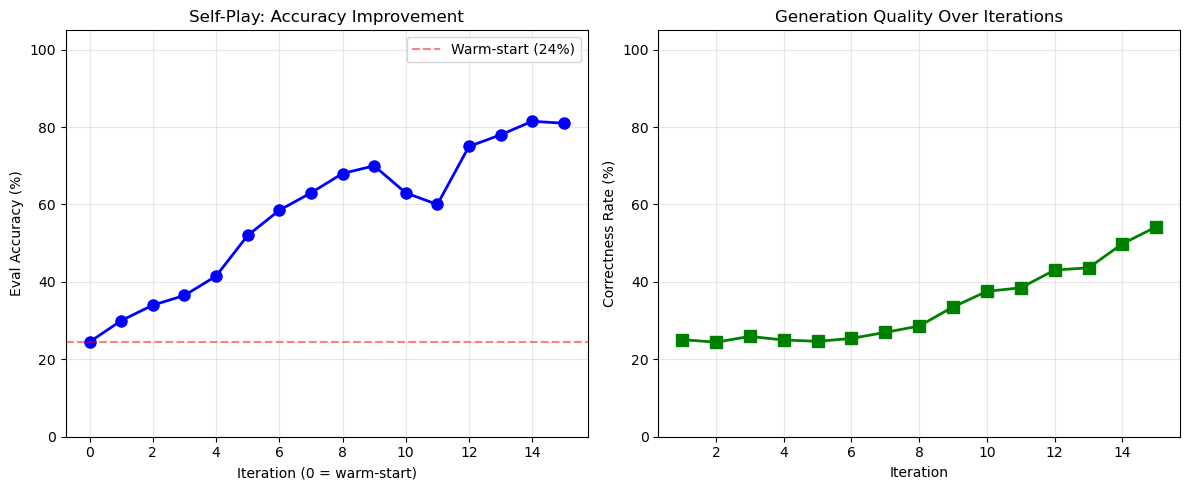

Saved: self_play_toy_results.png


In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Accuracy over iterations
accuracies = [baseline_accuracy] + results["iterations"]
ax1.plot(
    range(len(accuracies)),
    [a * 100 for a in accuracies],
    "b-o",
    linewidth=2,
    markersize=8,
)
ax1.axhline(
    y=baseline_accuracy * 100,
    color="r",
    linestyle="--",
    alpha=0.5,
    label=f"Warm-start ({baseline_accuracy * 100:.0f}%)",
)
ax1.set_xlabel("Iteration (0 = warm-start)")
ax1.set_ylabel("Eval Accuracy (%)")
ax1.set_title("Self-Play: Accuracy Improvement")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# Right: Correctness rate over iterations
ax2.plot(
    range(1, len(results["correctness_rates"]) + 1),
    [r * 100 for r in results["correctness_rates"]],
    "g-s",
    linewidth=2,
    markersize=8,
)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Correctness Rate (%)")
ax2.set_title("Generation Quality Over Iterations")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("self_play_toy_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: self_play_toy_results.png")

## Verify by Hand

Let's spot-check some predictions to convince ourselves the model actually learned addition.

In [8]:
print("Spot-check: model predictions vs ground truth")
print(f"{'Problem':<12} {'Predicted':<12} {'Correct':<10} {'Match':<6}")
print("-" * 42)

test_cases = [
    (1, 1),
    (3, 7),
    (5, 5),
    (9, 9),
    (2, 8),
    (4, 6),
    (7, 3),
    (1, 9),
    (8, 5),
    (6, 6),
]

correct_count = 0
for a, b in test_cases:
    predicted = model.predict(a, b, temperature=0.0)
    correct = a + b
    match = predicted == correct
    correct_count += match
    symbol = "Y" if match else "N"
    print(f"{a} + {b} = ?    {predicted:<12} {correct:<10} {symbol}")

print(f"\nSpot-check accuracy: {correct_count}/{len(test_cases)}")

Spot-check: model predictions vs ground truth
Problem      Predicted    Correct    Match 
------------------------------------------
1 + 1 = ?    2            2          Y
3 + 7 = ?    10           10         Y
5 + 5 = ?    10           10         Y
9 + 9 = ?    13           18         N
2 + 8 = ?    10           10         Y
4 + 6 = ?    10           10         Y
7 + 3 = ?    10           10         Y
1 + 9 = ?    10           10         Y
8 + 5 = ?    13           13         Y
6 + 6 = ?    12           12         Y

Spot-check accuracy: 9/10


## Key Takeaways

### What We Demonstrated

1. **Self-play works when there's headroom.** Starting from ~25% warm-start accuracy, the model reached 80%+ through iterative generate-verify-train cycles. The self-play phase used **no additional labeled data** — only a verifier (checking `predicted == a + b`).

2. **Bootstrapping matters.** The warm-start phase was essential. A random model (~6% accuracy) doesn't generate enough correct solutions to learn from reliably. This is exactly why pre-trained LLMs work for self-play but random models don't.

3. **Accumulation is key.** Each iteration adds newly discovered correct examples to a growing dataset. This expanding training set drives continuous improvement — the positive feedback loop at the heart of self-play.

4. **Correctness rate tracks improvement.** As the model gets better, it generates more correct solutions, which provides more training data, which makes it better. The correctness rate climbed from ~25% to ~50%+ over 15 iterations.

5. **The curve isn't always smooth.** Some iterations show small dips before continued improvement — this is normal variance from stochastic training, not a fundamental problem.

### Connection to Notebook 01

Notebook 01 applies this exact loop to a real LLM (Qwen2.5-3B-Instruct) on math word problems (GSM8K). There, the model starts at 86% baseline — already near its ceiling — and self-play causes accuracy to *decrease*. The contrast between this toy example (big improvement from low baseline) and Notebook 01 (degradation from high baseline) illustrates the critical importance of **headroom** in self-play.

### The Headroom Principle

| Baseline Accuracy | Self-Play Effect | Why |
|---|---|---|
| Too low (<5%) | No improvement | Not enough correct examples to learn from (cold-start) |
| Low-Medium (15-60%) | Strong improvement | Enough correct data to bootstrap, plenty of room to grow |
| High (>80%) | Diminishing returns / degradation | Training on known solutions narrows diversity |

### The Full Picture

```
Random weights ──[supervised]──> Warm-start (~25%) ──[self-play]──> High accuracy (80%+)
                 ↑                                    ↑
          Pre-training in LLMs                  STaR / ReST / RLHF
```

**Next:** See [Notebook 01](01_self_play_fundamentals.ipynb) for the full LLM implementation with multi-GPU generation, LoRA fine-tuning, and the ceiling effect in action.